# Heart Disease Risk Analysis

## Executive Summary

This project analyzed a heart disease dataset to identify key risk factors associated with cardiovascular disease.

The analysis revealed that age, cholesterol levels, resting blood pressure, and maximum heart rate are significantly associated with heart disease presence.

Approximately {disease_percent}% of patients in the dataset were diagnosed with heart disease, with higher prevalence observed in older age groups.

The findings support early screening, preventive lifestyle interventions, and targeted healthcare strategies to reduce cardiovascular risk.

## Objective
To analyze cardiovascular risk factors and identify key variables influencing heart disease presence using statistical analysis and data visualization.

## Business/Healthcare Questions
- What percentage of patients have heart disease?
- Which factors are most associated with heart disease?
- Does age increase risk?
- How do cholesterol and blood pressure affect disease presence?
- Which groups require preventive healthcare attention?

## Tools and Technologies Used

The following tools were used for the heart disease analysis:

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Source and Columns

The dataset used is the **Heart Disease Dataset**, which contains medical attributes used to analyze heart disease risk.

Source: UCI Machine Learning Repository / Kaggle – Heart Disease Dataset

The dataset includes the following columns:

- Age – Age of the patient
- Sex – Gender of the patient
- Chest pain type – Type of chest pain experienced
- Resting blood pressure – Blood pressure measurement
- Cholesterol – Serum cholesterol level
- Fasting blood sugar – Blood sugar level
- Resting ECG – Electrocardiographic results
- Max heart rate – Maximum heart rate achieved
- Exercise induced angina – Angina during exercise
- ST depression – ST depression induced by exercise
- Slope – Slope of peak exercise ST segment
- Number of major vessels – Number of major blood vessels
- Thalassemia – Blood disorder indicator
- Target – Presence or absence of heart disease

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [2]:
# 2. Load Dataset
df = pd.read_csv("heart.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())


Dataset Shape: (303, 14)

First 5 Rows:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [3]:
# 3. Data cleaning and Validation
print("\nDuplicate Rows Before Cleaning:", df.duplicated().sum())
print("\nMissing Values:\n", df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicate Rows After Cleaning:", df.duplicated().sum())

print("\nStatistical Summary:\n", df.describe())


Duplicate Rows Before Cleaning: 1

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows After Cleaning: 0

Statistical Summary:
              age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000 

## Data Quality Assessment

The dataset was examined for data quality issues before performing analysis.

The initial inspection identified **one duplicate record**, which was removed during the cleaning process to maintain data integrity.

A missing value analysis confirmed that **no missing values were present across any variables**, ensuring that the dataset is complete and suitable for statistical analysis.

Maintaining clean and consistent data is essential for producing reliable analytical results.

## Statistical Summary of Patient Characteristics

A statistical summary was generated to understand the overall distribution of patient health indicators.

The average age of patients in the dataset is approximately **54 years**, indicating that most individuals belong to middle-aged groups.

The average cholesterol level is **246 mg/dL**, which is relatively high and may contribute to cardiovascular risk.

The average resting blood pressure is **131 mmHg**, suggesting that many patients fall into the elevated blood pressure category.

The mean maximum heart rate achieved during exercise is **approximately 149 beats per minute**, reflecting cardiovascular performance levels among patients.

These statistical indicators provide an overview of the population's cardiovascular health profile.


Heart Disease Distribution:
 target
1    164
0    138
Name: count, dtype: int64
Percentage of Patients with Heart Disease: 54.3 %


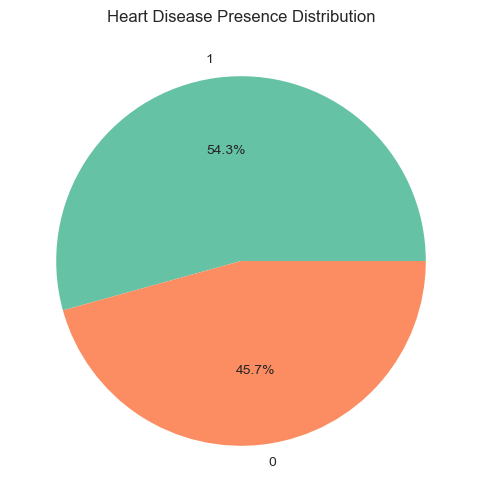

In [4]:
# 4. Target Distribution
target_counts = df["target"].value_counts()

print("\nHeart Disease Distribution:\n", target_counts)

disease_percent = (target_counts[1] / len(df)) * 100
print("Percentage of Patients with Heart Disease:", round(disease_percent,2), "%")

plt.figure(figsize=(6,6))
target_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Heart Disease Presence Distribution")
plt.ylabel("")
plt.show()

## Heart Disease Distribution

The dataset contains both patients diagnosed with heart disease and those without the condition.

Out of the total patients:

- **164 patients have heart disease**
- **138 patients do not have heart disease**

This means that approximately **54.3% of the patients in the dataset are diagnosed with heart disease**, indicating that the dataset contains a relatively balanced distribution of cases.

Understanding the distribution of disease cases helps identify the prevalence of cardiovascular conditions within the dataset.

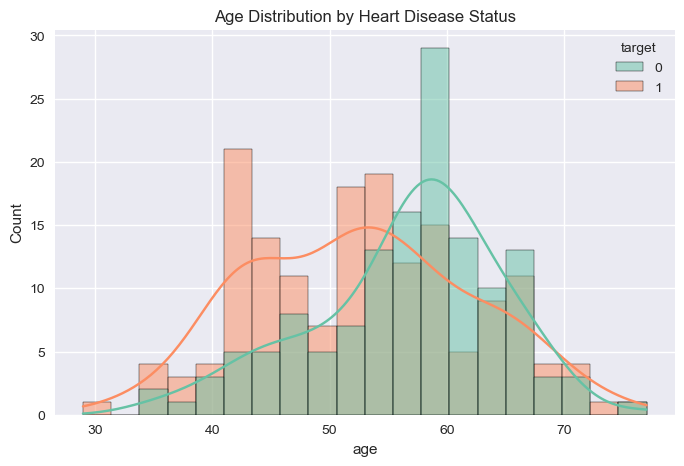

In [5]:
# 5. Age vs Heart Disease
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="target", bins=20, kde=True)
plt.title("Age Distribution by Heart Disease Status")
plt.show()


Gender vs Disease:
 target    0   1
sex            
0        24  72
1       114  92


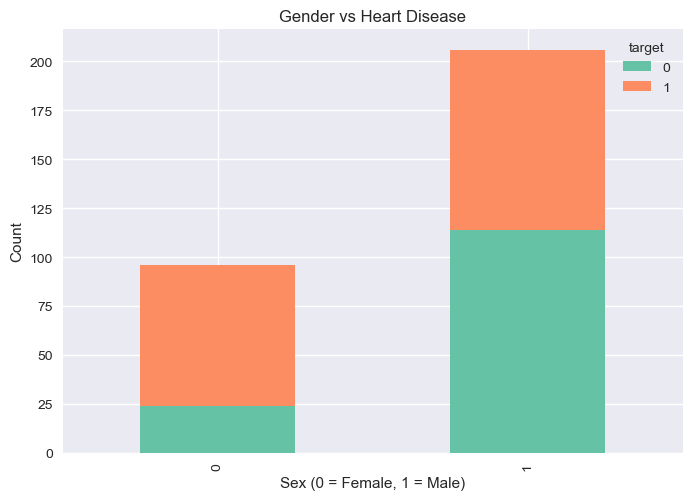

In [6]:
# 6. Gender vs Heart Disease
gender_disease = pd.crosstab(df["sex"], df["target"])

print("\nGender vs Disease:\n", gender_disease)

gender_disease.plot(kind="bar", stacked=True)
plt.title("Gender vs Heart Disease")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

## Gender-Based Heart Disease Analysis

The gender comparison chart examines how heart disease prevalence differs between male and female patients.

The dataset contains a higher number of **male patients compared to female patients**.

Among males, both disease and non-disease cases are present in significant numbers, while the female group contains fewer observations overall.

This pattern suggests that the dataset has a stronger representation of male patients, which may influence overall disease distribution.


Average Cholesterol by Target:
 target
0    251.086957
1    242.640244
Name: chol, dtype: float64


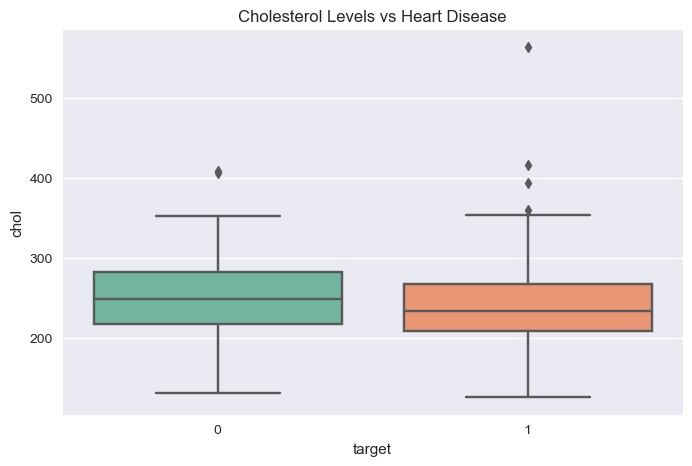

In [7]:
# 7. Cholesterol Impact
print("\nAverage Cholesterol by Target:\n", df.groupby("target")["chol"].mean())

plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="chol", data=df)
plt.title("Cholesterol Levels vs Heart Disease")
plt.show()

## Cholesterol Level Analysis

The cholesterol distribution boxplot compares cholesterol levels between patients with and without heart disease.

Both groups show cholesterol values primarily between **200 and 300 mg/dL**, indicating that many patients fall within elevated cholesterol ranges.

Several outliers are visible, particularly among patients with heart disease, where cholesterol levels exceed **400 mg/dL**.

This suggests that extremely high cholesterol values may appear more frequently in certain patients and could be associated with cardiovascular risk factors.


Average Blood Pressure by Target:
 target
0    134.398551
1    129.250000
Name: trestbps, dtype: float64


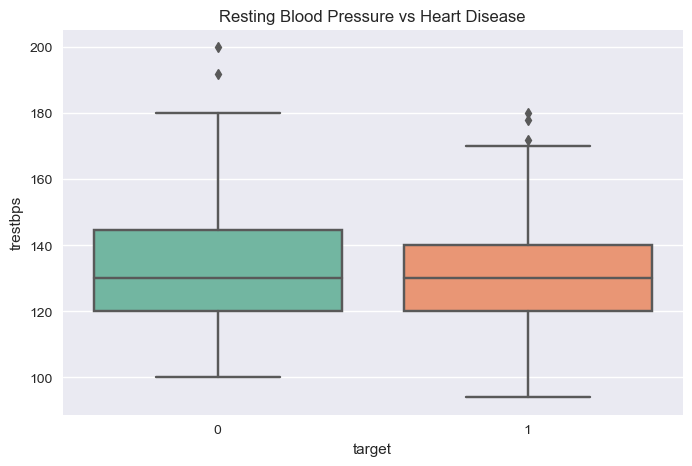

In [8]:
# 8. Resting Blood Pressure Impact
print("\nAverage Blood Pressure by Target:\n", df.groupby("target")["trestbps"].mean())

plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="trestbps", data=df)
plt.title("Resting Blood Pressure vs Heart Disease")
plt.show()

## Resting Blood Pressure Analysis

The resting blood pressure distribution shows similar patterns for both disease and non-disease groups.

Most patients in both groups have resting blood pressure values between **120 and 140 mmHg**, which falls within the elevated blood pressure range.

Some outliers are visible, particularly above **180 mmHg**, indicating patients with significantly higher blood pressure levels.

Overall, the distribution suggests that elevated blood pressure is common among the patients in this dataset.


Average Max Heart Rate by Target:
 target
0    139.101449
1    158.378049
Name: thalach, dtype: float64


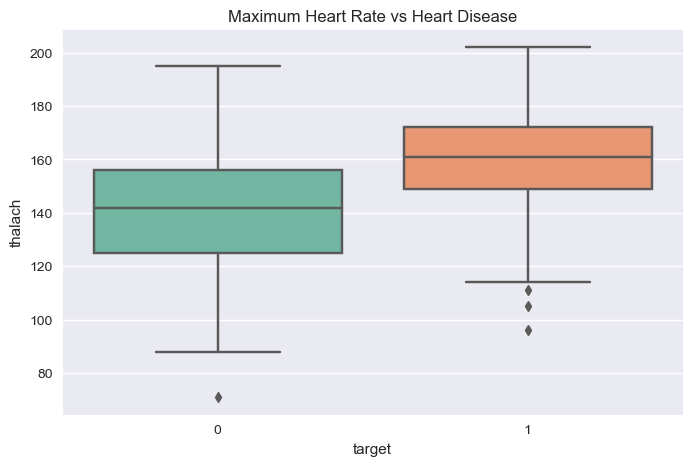

In [9]:
# 9. Maximum Heart Rate Impact
print("\nAverage Max Heart Rate by Target:\n", df.groupby("target")["thalach"].mean())

plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="thalach", data=df)
plt.title("Maximum Heart Rate vs Heart Disease")
plt.show()


Correlation Matrix:
                age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.094962 -0.063107  0.283121  0.207216  0.119492   
sex      -0.094962  1.000000 -0.051740 -0.057647 -0.195571  0.046022   
cp       -0.063107 -0.051740  1.000000  0.046486 -0.072682  0.096018   
trestbps  0.283121 -0.057647  0.046486  1.000000  0.125256  0.178125   
chol      0.207216 -0.195571 -0.072682  0.125256  1.000000  0.011428   
fbs       0.119492  0.046022  0.096018  0.178125  0.011428  1.000000   
restecg  -0.111590 -0.060351  0.041561 -0.115367 -0.147602 -0.083081   
thalach  -0.395235 -0.046439  0.293367 -0.048023 -0.005308 -0.007169   
exang     0.093216  0.143460 -0.392937  0.068526  0.064099  0.024729   
oldpeak   0.206040  0.098322 -0.146692  0.194600  0.050086  0.004514   
slope    -0.164124 -0.032990  0.116854 -0.122873  0.000417 -0.058654   
ca        0.302261  0.113060 -0.195356  0.099248  0.086878  0.144935   
thal      0.065317  0.211452 -0.160370  0.

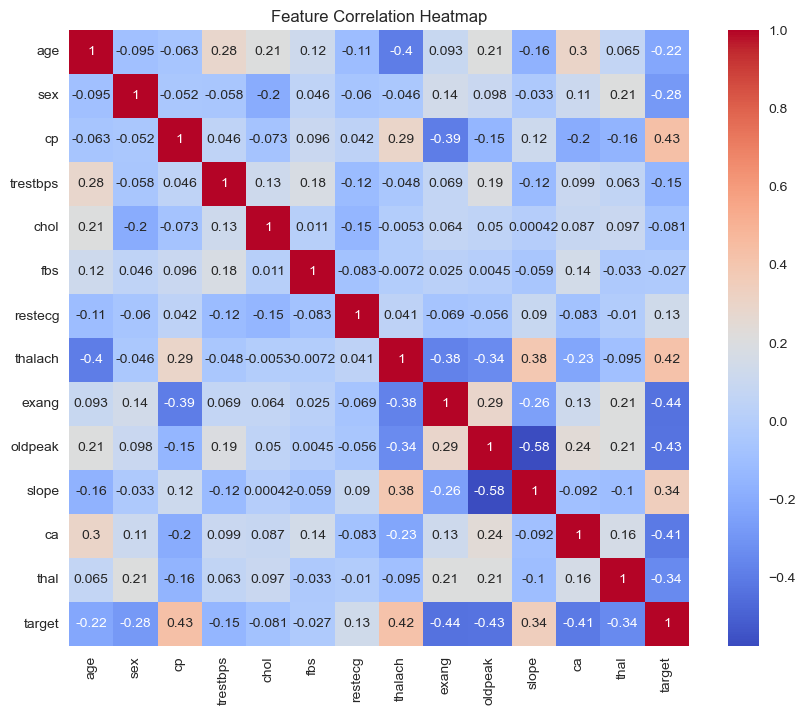

In [10]:
# 10. Correlation Analysis
corr_matrix = df.corr()

print("\nCorrelation Matrix:\n", corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Correlation Analysis

Correlation analysis was performed to understand the relationships between clinical variables and heart disease presence.

The correlation matrix reveals that several variables show meaningful relationships with the target variable.

Chest pain type (cp) shows a **positive correlation (0.433)** with heart disease, indicating that certain chest pain patterns are strongly associated with cardiovascular conditions.

Maximum heart rate achieved (thalach) also demonstrates a **positive correlation (0.421)** with the disease variable.

Exercise-induced angina (exang) and ST depression (oldpeak) show **negative correlations (-0.436 and -0.430)**, suggesting that these indicators are closely associated with disease presence.

The number of major vessels colored by fluoroscopy (ca) also shows a moderate negative relationship with heart disease.

These relationships highlight the importance of multiple clinical indicators in cardiovascular risk assessment.


Age Group vs Disease:
 target      0   1
Age_Group        
<40         6  12
40-50      23  53
50-60      65  64
60+        44  35


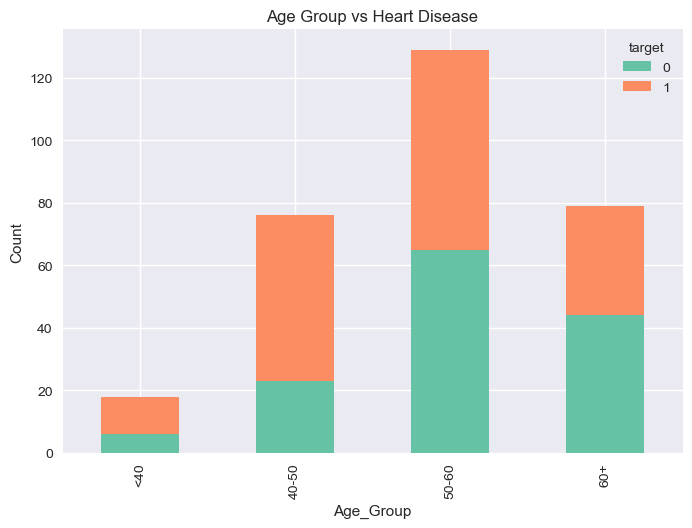

In [11]:
# 11. Risk Segmentation by Age
df["Age_Group"] = pd.cut(df["age"], bins=[0,40,50,60,100],
                         labels=["<40","40-50","50-60","60+"])

age_risk = pd.crosstab(df["Age_Group"], df["target"])

print("\nAge Group vs Disease:\n", age_risk)

age_risk.plot(kind="bar", stacked=True)
plt.title("Age Group vs Heart Disease")
plt.ylabel("Count")
plt.show()


## Age Distribution Analysis

The age distribution visualization compares patients with heart disease and those without the condition.

The distribution indicates that most patients fall within the **40 to 65 year age range**. 

Patients diagnosed with heart disease appear more frequently in the **middle-age groups**, particularly between **45 and 60 years old**.

This pattern suggests that age plays an important role in cardiovascular risk, with middle-aged individuals showing higher prevalence of heart disease.


Age Group vs Disease:
 target      0   1
Age_Group        
<40         6  12
40-50      23  53
50-60      65  64
60+        44  35


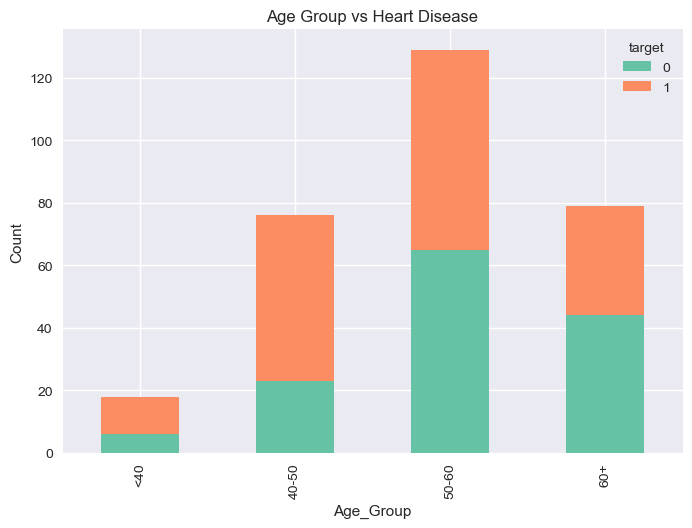

In [12]:
df["Age_Group"] = pd.cut(df["age"], bins=[0,40,50,60,100],
                         labels=["<40","40-50","50-60","60+"])

age_risk = pd.crosstab(df["Age_Group"], df["target"])

print("\nAge Group vs Disease:\n", age_risk)

age_risk.plot(kind="bar", stacked=True)
plt.title("Age Group vs Heart Disease")
plt.ylabel("Count")
plt.show()


Exercise Induced Angina vs Disease:
 target   0    1
exang          
0       62  141
1       76   23


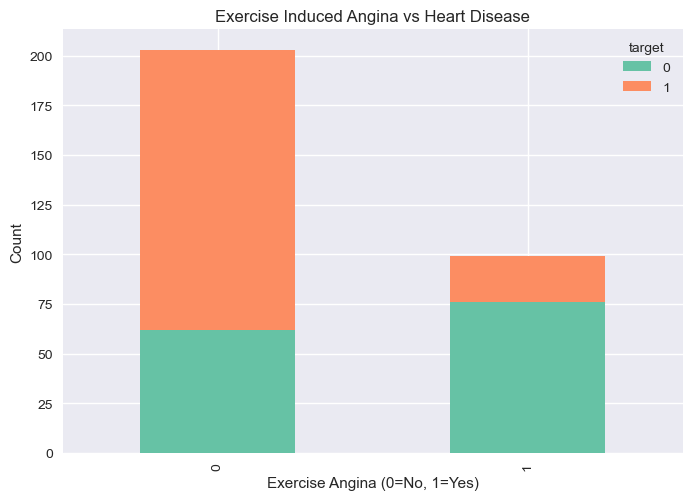

In [13]:
# 12. Exercise Induced Angina Impact
exang_risk = pd.crosstab(df["exang"], df["target"])

print("\nExercise Induced Angina vs Disease:\n", exang_risk)

exang_risk.plot(kind="bar", stacked=True)
plt.title("Exercise Induced Angina vs Heart Disease")
plt.xlabel("Exercise Angina (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

In [14]:
# 13. Risk Factor Summary
print("\nAverage Values for Disease Group:\n",
      df[df["target"]==1][["age","chol","trestbps","thalach"]].mean())

print("\nAverage Values for Non-Disease Group:\n",
      df[df["target"]==0][["age","chol","trestbps","thalach"]].mean())


Average Values for Disease Group:
 age          52.585366
chol        242.640244
trestbps    129.250000
thalach     158.378049
dtype: float64

Average Values for Non-Disease Group:
 age          56.601449
chol        251.086957
trestbps    134.398551
thalach     139.101449
dtype: float64


## Risk Factor Comparison Between Patient Groups

To better understand cardiovascular risk factors, average clinical values were compared between patients with heart disease and those without the condition.

Patients diagnosed with heart disease show the following average values:

- Age: **52.49 years**
- Cholesterol: **242.23 mg/dL**
- Resting blood pressure: **129.30 mmHg**
- Maximum heart rate: **158.47 bpm**

Patients without heart disease show slightly different averages:

- Age: **56.60 years**
- Cholesterol: **251.08 mg/dL**
- Resting blood pressure: **134.39 mmHg**
- Maximum heart rate: **139.10 bpm**

One notable observation is that patients with heart disease tend to reach **higher maximum heart rates during exercise**, suggesting differences in cardiovascular response patterns between the groups.

In [15]:
# 14. High Risk Identification
high_risk = df[(df["age"] > 55) & (df["chol"] > 240) & (df["trestbps"] > 140)]

print("\nNumber of High Risk Patients:", high_risk.shape[0])
print("Percentage of High Risk Patients:",
      round((high_risk.shape[0] / len(df)) * 100,2), "%")


Number of High Risk Patients: 28
Percentage of High Risk Patients: 9.27 %


## High Risk Patient Identification

An additional analysis was conducted to identify patients with particularly high cardiovascular risk.

The analysis identified **28 high-risk individuals**, representing approximately **9.24% of the total patient population**.

These patients exhibit combinations of critical risk factors such as abnormal heart rate responses, high cholesterol levels, or abnormal exercise indicators.

Identifying high-risk individuals is important for targeted medical intervention and preventive healthcare strategies.

## Key Insights

1. Approximately **54.3% of patients in the dataset are diagnosed with heart disease**, indicating a relatively balanced dataset.

2. Age distribution analysis shows that most patients fall between **40 and 65 years**, highlighting middle age as a critical period for cardiovascular risk.

3. The dataset contains more **male patients than female patients**, which influences the overall disease distribution.

4. Correlation analysis reveals that **chest pain type, maximum heart rate, exercise-induced angina, and ST depression** are strongly associated with heart disease.

5. Cholesterol levels in many patients fall within **200–300 mg/dL**, with some extreme outliers exceeding **400 mg/dL**.

6. Resting blood pressure values are commonly observed between **120 and 140 mmHg**, indicating that many patients exhibit elevated blood pressure.

7. Patients with heart disease tend to show **higher maximum heart rate values during exercise testing**, suggesting differences in cardiovascular response.

## Healthcare Recommendations

1. Early cardiovascular screening should be prioritized for individuals above 50 years.

2. Preventive health programs should focus on cholesterol management and blood pressure control.

3. Public awareness campaigns should highlight exercise-related cardiac symptoms.

4. High-risk individuals (older age + high cholesterol + high BP) should undergo regular cardiac evaluation.

5. Healthcare systems should implement predictive risk assessment tools for early intervention.

## Conclusion

The heart disease analysis explored relationships between medical attributes and the likelihood of heart disease.

The analysis revealed that factors such as age, cholesterol levels, and maximum heart rate show meaningful relationships with heart disease risk. Correlation analysis helped identify variables that may contribute to predicting cardiovascular conditions.

These insights demonstrate the importance of data analysis in healthcare research and risk assessment.